In [1]:
import os, time
import pandas as pd
from influxdb_client_3 import InfluxDBClient3, Point

token = os.environ.get("INFLUXDB_TOKEN")
org = "CS 218"
host = "https://us-east-1-1.aws.cloud2.influxdata.com"

client = InfluxDBClient3(host=host, database="article_test", token=token, org=org)

# Get News and score value
query = """
SELECT company, score, time
FROM "news_articles"
WHERE ("score" != 101)
ORDER BY time DESC
"""
score_table = client.query(query=query, language='sql')

df_score_table = score_table.to_pandas()


In [2]:
df_score_table = df_score_table.sort_values(by=['company', 'time'], ascending=[True, True])
df_score_table = df_score_table.reset_index(drop=True)


In [42]:
df_score_table

,company,score,time
0,Amazon,-4,2024-09-20 10:57:06
1,Amazon,2,2024-09-24 17:25:09
2,Amazon,7,2024-09-25 14:44:58
3,Amazon,7,2024-09-25 15:38:19
4,Amazon,2,2024-09-25 19:54:07
...,...,...,...
1368,Nvidia,-4,2024-10-23 14:19:00
1369,Nvidia,-7,2024-10-23 14:41:25
1370,Nvidia,8,2024-10-23 14:54:32
1371,Nvidia,6,2024-10-23 15:00:00


In [3]:
client = InfluxDBClient3(host=host, database="stock_value_daily", token=token, org=org)

# Get daily stock value
query = """
SELECT *
FROM "stock_data"
ORDER BY time DESC
"""
daily_table = client.query(query=query, language='sql')

df_daily_table = daily_table.to_pandas()

print(df_daily_table)
print('-'*100)

client = InfluxDBClient3(host=host, database="stock_value_hourly", token=token, org=org)

hourly_table = client.query(query=query, language='sql')

df_hourly_table = hourly_table.to_pandas()

print(df_hourly_table)
print('-'*100)


     close_price  high_price interval  low_price  open_price ticker  \
0         235.86    236.2200      day    232.600     233.885   AAPL   
1         189.70    191.5201      day    186.975     188.350   AMZN   
2         165.14    165.7700      day    162.980     162.980  GOOGL   
3         582.01    583.5300      day    572.120     574.290   META   
4         143.59    144.4200      day    141.780     142.910   NVDA   
..           ...         ...      ...        ...         ...    ...   
115       228.87    229.8200      day    224.630     224.990   AAPL   
116       189.87    190.9900      day    188.470     190.040   AMZN   
117       162.14    163.7900      day    161.340     163.710  GOOGL   
118       559.10    562.0700      day    546.520     550.000   META   
119       117.87    119.6600      day    117.250     117.350   NVDA   

                   time     volume      vwap  
0   2024-10-22 04:00:00   35412947  234.8426  
1   2024-10-22 04:00:00   29171135  189.6999  
2   20

In [4]:
df_stock_table = pd.concat([df_daily_table, df_hourly_table], ignore_index=True)
df_stock_table = df_stock_table.sort_values(by=['ticker', 'time'], ascending=[True, True])
df_stock_table = df_stock_table.reset_index(drop=True)


# Edit ticker to company name 
ticker_to_company = {
    'AAPL': 'Apple',
    'AMZN': 'Amazon',
    'GOOGL': 'Google',
    'META': 'Meta',
    'NVDA': 'Nvidia'
}

df_stock_table['ticker'] = df_stock_table['ticker'].replace(ticker_to_company)
df_stock_table = df_stock_table.rename(columns={'ticker': 'company'})

# Print the combined DataFrame
print(df_stock_table)


      close_price  high_price interval  low_price  open_price company  \
0          228.87      229.82      day     224.63      224.99   Apple   
1          224.50      224.76     hour     222.79      222.79   Apple   
2          224.38      224.49     hour     223.87      224.34   Apple   
3          224.84      224.85     hour     224.13      224.23   Apple   
4          224.70      224.89     hour     224.01      224.50   Apple   
...           ...         ...      ...        ...         ...     ...   
2035       143.57      143.86     hour     143.21      143.30  Nvidia   
2036       143.56      143.62     hour     143.12      143.58  Nvidia   
2037       143.34      143.59     hour     143.24      143.56  Nvidia   
2038       143.20      143.37     hour     143.10      143.33  Nvidia   
2039       143.33      143.47     hour     143.18      143.18  Nvidia   

                    time    volume      vwap  
0    2024-09-19 04:00:00  65015591  228.3850  
1    2024-09-19 08:00:00     

In [5]:
print(df_stock_table.head(20))
print('-'*100)
print(df_stock_table.tail(20))


    close_price  high_price interval  low_price  open_price company  \
0      228.8700    229.8200      day   224.6300    224.9900   Apple   
1      224.5000    224.7600     hour   222.7900    222.7900   Apple   
2      224.3800    224.4900     hour   223.8700    224.3400   Apple   
3      224.8400    224.8500     hour   224.1300    224.2300   Apple   
4      224.7000    224.8900     hour   224.0100    224.5000   Apple   
5      225.1050    225.2900     hour   223.0000    224.1400   Apple   
6      227.3000    227.4200     hour   224.6300    225.1000   Apple   
7      227.9400    229.8200     hour   227.2300    227.2900   Apple   
8      228.3700    228.8699     hour   227.6600    227.9600   Apple   
9      229.1800    229.3300     hour   228.2800    228.3700   Apple   
10     229.3800    229.4600     hour   228.7150    229.1800   Apple   
11     229.3200    229.4400     hour   228.4000    229.3800   Apple   
12     228.8100    229.5900     hour   228.2800    229.3200   Apple   
13    

In [6]:
print(df_stock_table.info())
print(df_score_table.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   close_price  2040 non-null   float64       
 1   high_price   2040 non-null   float64       
 2   interval     2040 non-null   object        
 3   low_price    2040 non-null   float64       
 4   open_price   2040 non-null   float64       
 5   company      2040 non-null   object        
 6   time         2040 non-null   datetime64[ns]
 7   volume       2040 non-null   int64         
 8   vwap         2040 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 143.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   company  1373 non-null   object        
 1   score    1373 non-nul

# Important note: Daily stock is the daily value on that timestamp day (even if the timestamp says 4am)


# Table by content (all panda dataframes)
- - df_stock_table: stock table sorted by ticker and time (all tickers are together)

     Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   close_price  2040 non-null   float64       
 1   high_price   2040 non-null   float64       
 2   interval     2040 non-null   object        
 3   low_price    2040 non-null   float64       
 4   open_price   2040 non-null   float64       
 5   company      2040 non-null   object        
 6   time         2040 non-null   datetime64 <br>
 7   volume       2040 non-null   int64         
 8   vwap         2040 non-null   float64       

- df_score_table: news article and score sorted by company and time (ascending) (all companies news follow one another in the table)

     Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   company  1373 non-null   object        
 1   score    1373 non-null   int64         
 2   time     1373 non-null   datetime64


# Machine learning content starts here

In [49]:

# function to filter and ensure timezone-naive time columns
def filter_and_localize(df, condition):
    """
    Filter the DataFrame based on a condition and ensure the 'time' column is timezone-naive.
    """
    filtered_df = df[condition].copy()  # Ensure a copy to avoid SettingWithCopyWarning
    filtered_df['time'] = filtered_df['time'].dt.tz_localize(None)  # Localize to naive timezone
    return filtered_df


is_amazon = df_score_table['company'] == 'Amazon'
is_google = df_score_table['company'] == 'Google'
is_apple = df_score_table['company'] == 'Apple'
is_meta = df_score_table['company'] == 'Meta'
is_nvidia = df_score_table['company'] == 'Nvidia'
df_score_table['time'] = pd.to_datetime(df_score_table['time'])
df_stock_table['time'] = pd.to_datetime(df_stock_table['time'])


# Split score data for each company
nvidia_score = filter_and_localize(df_score_table, df_score_table['company'] == 'Nvidia')
meta_score = filter_and_localize(df_score_table, df_score_table['company'] == 'Meta')
apple_score = filter_and_localize(df_score_table, df_score_table['company'] == 'Apple')
amazon_score = filter_and_localize(df_score_table, df_score_table['company'] == 'Amazon')
google_score = filter_and_localize(df_score_table, df_score_table['company'] == 'Google')

# Split stock data for each company and interval type
nvidia_stock_daily = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Nvidia') & (df_stock_table['interval'] == 'day'))
nvidia_stock_hourly = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Nvidia') & (df_stock_table['interval'] == 'hour'))

meta_stock_daily = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Meta') & (df_stock_table['interval'] == 'day'))
meta_stock_hourly = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Meta') & (df_stock_table['interval'] == 'hour'))

apple_stock_daily = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Apple') & (df_stock_table['interval'] == 'day'))
apple_stock_hourly = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Apple') & (df_stock_table['interval'] == 'hour'))

amazon_stock_daily = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Amazon') & (df_stock_table['interval'] == 'day'))
amazon_stock_hourly = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Amazon') & (df_stock_table['interval'] == 'hour'))

google_stock_daily = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Google') & (df_stock_table['interval'] == 'day'))
google_stock_hourly = filter_and_localize(df_stock_table, (df_stock_table['company'] == 'Google') & (df_stock_table['interval'] == 'hour'))




In [50]:
google_stock_daily

,close_price,high_price,interval,low_price,open_price,company,time,volume,vwap
816,162.14,163.7900,day,161.3400,163.710,Google,2024-09-19 04:00:00,25118585,162.5776
833,163.59,163.7300,day,162.0600,163.500,Google,2024-09-20 04:00:00,36624248,163.3067
850,161.85,165.4900,day,161.6700,164.350,Google,2024-09-23 04:00:00,21661997,162.8848
867,162.29,163.2158,day,160.6900,163.030,Google,2024-09-24 04:00:00,22892713,162.2437
884,161.49,162.8100,day,161.3000,161.470,Google,2024-09-25 04:00:00,18361127,161.8617
901,162.73,164.0800,day,162.2800,163.640,Google,2024-09-26 04:00:00,19449441,162.9357
918,163.95,165.7000,day,162.6261,162.810,Google,2024-09-27 04:00:00,20482712,164.2054
935,165.85,166.1500,day,163.2600,163.320,Google,2024-09-30 04:00:00,19680893,165.1295
952,166.99,169.1600,day,164.5800,167.685,Google,2024-10-01 04:00:00,27453077,166.7083
969,165.86,167.5200,day,164.7300,166.420,Google,2024-10-02 04:00:00,17234517,165.6713


In [75]:
def calculate_average(df, start_time, end_time, column='score'):
    """
    Calculate the average of a column between two timestamps.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        start_time (str or pd.Timestamp): The start time for the filter.
        end_time (str or pd.Timestamp): The end time for the filter.
        column (str): The column to calculate the average for. Default is 'score'.
        
    Returns:
        float: The average value of the specified column within the time range.
    """
    # Ensure 'time' column is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Check if start_time and end_time are timezone-aware
    if start_time.tz is not None and end_time.tz is not None:
        # Make the 'time' column timezone-aware only if it's naive
        if df['time'].dt.tz is None:
            df['time'] = df['time'].dt.tz_localize('UTC')  # Localize as UTC if naive
    else:
        # Make the 'time' column timezone-naive
        if df['time'].dt.tz is not None:
            df['time'] = df['time'].dt.tz_localize(None)

    # Filter rows within the given time range
    filtered_df = df[(df['time'] >= pd.Timestamp(start_time)) & (df['time'] <= pd.Timestamp(end_time))]

    if not filtered_df.empty:
        # Calculate and return the average of the specified column
        return filtered_df[column].mean()
    else:
        return 0

def calculate_price_difference(df, start_time, end_time):
    """
    Calculate the close price - open price difference and percentage change for all stocks 
    within a given time range, including the timestamp.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing stock data.
        start_time (str or pd.Timestamp): The start time for filtering.
        end_time (str or pd.Timestamp): The end time for filtering.

    Returns:
        pd.DataFrame: A DataFrame containing 'time', 'price_difference', and 'percentage_change'.
    """
    # Ensure 'time' column is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Check if start_time and end_time are timezone-aware
    if start_time.tz is not None and end_time.tz is not None:
        # Ensure 'time' column is timezone-aware
        if df['time'].dt.tz is None:
            df['time'] = df['time'].dt.tz_localize('UTC')  # Localize as UTC if naive
    else:
        # Ensure 'time' column is timezone-naive
        if df['time'].dt.tz is not None:
            df['time'] = df['time'].dt.tz_localize(None)

    # Filter the DataFrame based on the time range
    filtered_df = df[(df['time'] >= pd.Timestamp(start_time)) & (df['time'] <= pd.Timestamp(end_time))].copy()

    # Calculate price difference and percentage change
    if not filtered_df.empty:
        filtered_df['price_difference'] = filtered_df['close_price'] - filtered_df['open_price']
        filtered_df['percentage_change'] = (filtered_df['price_difference'] / filtered_df['open_price']) * 100
        return filtered_df[['time', 'price_difference', 'percentage_change']]
    else:
        # Return an empty DataFrame with the appropriate columns
        return pd.DataFrame(columns=['time', 'price_difference', 'percentage_change'])



In [52]:
start_time = pd.Timestamp('2024-09-19 10:00:00', tz='UTC')

end_time = pd.Timestamp('2024-09-23 11:00:00', tz='UTC')


# Calculate the average score
average_score = calculate_average(google_score, start_time, end_time, column='score')
if pd.isna(average_score):
    average_score = 0
print("Average Score:", average_score)


Average Score: 3.2857142857142856


In [53]:
price_differences = calculate_price_difference(google_stock_daily, start_time, end_time)
print("Price Differences:", price_differences)

Price Differences: [0.05504587155963511, -1.5211439002129603]


In [62]:
def calculate_means_score_over_time(df, start_time, end_time, column, increment):
    """
    Calculate the mean of a specified column over incremental time ranges in a DataFrame.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing the data.
        start_time (str or pd.Timestamp): The starting timestamp for the calculation.
        end_time (str or pd.Timestamp): The ending timestamp for the calculation.
        column (str): The column for which the mean is calculated.
        increment (pd.Timedelta): The time increment for each interval.

    Returns:
        pd.DataFrame: A DataFrame with the start_time, end_time, and calculated mean for each interval.
    """
    # Ensure 'time' column is datetime
    if 'time' not in df.columns:
        raise ValueError("The input DataFrame must have a 'time' column.")
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Initialize results list
    results = []

    # Loop through the time intervals
    current_start = pd.Timestamp(start_time)
    current_end = pd.Timestamp(start_time) + increment
    while current_start < pd.Timestamp(end_time):
        # Filter data within the interval
        filtered_df = df[(df['time'] >= current_start) & (df['time'] < current_end)]
        # Calculate the mean, return 0 if no data
        mean_value = filtered_df[column].mean() if not filtered_df.empty else 0
        # Append results
        results.append({'start_time': current_start, 'end_time': current_end, 'mean_value': mean_value})
        # Increment the time window
        current_start += increment
        current_end += increment

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    return results_df

In [81]:
increment = pd.Timedelta(hours=1)
start_time = pd.Timestamp('2024-09-19 10:00:00')
end_time = pd.Timestamp('2024-10-23 11:00:00')

mean_score_over_time_google = calculate_means_score_over_time(google_score, start_time, end_time, column='score', increment=increment)
mean_score_over_time_meta = calculate_means_score_over_time(meta_score, start_time, end_time, column='score', increment=increment)
mean_score_over_time_amazon = calculate_means_score_over_time(amazon_score, start_time, end_time, column='score', increment=increment)
mean_score_over_time_apple = calculate_means_score_over_time(apple_score, start_time, end_time, column='score', increment=increment)
mean_score_over_time_nvidia = calculate_means_score_over_time(nvidia_score, start_time, end_time, column='score', increment=increment)

change_stock_hourly_google = calculate_price_difference(google_stock_hourly, start_time, end_time)
change_stock_daily_google = calculate_price_difference(google_stock_daily, start_time, end_time)

change_stock_hourly_meta = calculate_price_difference(meta_stock_hourly, start_time, end_time)
change_stock_daily_meta = calculate_price_difference(meta_stock_daily, start_time, end_time)

change_stock_hourly_amazon = calculate_price_difference(amazon_stock_hourly, start_time, end_time)
change_stock_daily_amazon = calculate_price_difference(amazon_stock_daily, start_time, end_time)

change_stock_hourly_apple = calculate_price_difference(apple_stock_hourly, start_time, end_time)
change_stock_daily_apple = calculate_price_difference(apple_stock_daily, start_time, end_time)

change_stock_hourly_nvidia = calculate_price_difference(nvidia_stock_hourly, start_time, end_time)
change_stock_daily_nvidia = calculate_price_difference(nvidia_stock_daily, start_time, end_time)

In [91]:
# combine the dataframes
import pandas as pd

# Add a company column to each sentiment DataFrame
mean_score_over_time_google['company'] = 'Google'
mean_score_over_time_meta['company'] = 'Meta'
mean_score_over_time_amazon['company'] = 'Amazon'
mean_score_over_time_apple['company'] = 'Apple'
mean_score_over_time_nvidia['company'] = 'Nvidia'

# Rename start_time to time in sentiment data
mean_score_over_time_google.rename(columns={'start_time': 'time'}, inplace=True)
mean_score_over_time_meta.rename(columns={'start_time': 'time'}, inplace=True)
mean_score_over_time_amazon.rename(columns={'start_time': 'time'}, inplace=True)
mean_score_over_time_apple.rename(columns={'start_time': 'time'}, inplace=True)
mean_score_over_time_nvidia.rename(columns={'start_time': 'time'}, inplace=True)


# Combine sentiment DataFrames
sentiment_data = pd.concat([
    mean_score_over_time_google,
    mean_score_over_time_meta,
    mean_score_over_time_amazon,
    mean_score_over_time_apple,
    mean_score_over_time_nvidia
], ignore_index=True)

sentiment_data.rename(columns={'mean_value':'average_sentiment'}, inplace=True)

# Add a company column to each stock DataFrame
change_stock_hourly_google['company'] = 'Google'
change_stock_daily_google['company'] = 'Google'

change_stock_hourly_meta['company'] = 'Meta'
change_stock_daily_meta['company'] = 'Meta'

change_stock_hourly_amazon['company'] = 'Amazon'
change_stock_daily_amazon['company'] = 'Amazon'

change_stock_hourly_apple['company'] = 'Apple'
change_stock_daily_apple['company'] = 'Apple'

change_stock_hourly_nvidia['company'] = 'Nvidia'
change_stock_daily_nvidia['company'] = 'Nvidia'

# Combine hourly stock DataFrames
stock_data_hourly = pd.concat([
    change_stock_hourly_google,
    change_stock_hourly_meta,
    change_stock_hourly_amazon,
    change_stock_hourly_apple,
    change_stock_hourly_nvidia
], ignore_index=True)

# Combine daily stock DataFrames
stock_data_daily = pd.concat([
    change_stock_daily_google,
    change_stock_daily_meta,
    change_stock_daily_amazon,
    change_stock_daily_apple,
    change_stock_daily_nvidia
], ignore_index=True)

# Merge sentiment and stock data for hourly and daily
print(sentiment_data)
merged_hourly = pd.merge(sentiment_data, stock_data_hourly, on=['time', 'company'], how='inner')
merged_daily = pd.merge(sentiment_data, stock_data_daily, on=['time', 'company'], how='inner')

# View the merged DataFrames
print("Merged Hourly Data:")
print(merged_hourly.head())

print("\nMerged Daily Data:")
print(merged_daily.head())


                    time            end_time  average_sentiment company
0    2024-09-19 10:00:00 2024-09-19 11:00:00           0.000000  Google
1    2024-09-19 11:00:00 2024-09-19 12:00:00           0.000000  Google
2    2024-09-19 12:00:00 2024-09-19 13:00:00           0.000000  Google
3    2024-09-19 13:00:00 2024-09-19 14:00:00           0.000000  Google
4    2024-09-19 14:00:00 2024-09-19 15:00:00           0.000000  Google
...                  ...                 ...                ...     ...
4080 2024-10-23 06:00:00 2024-10-23 07:00:00           0.000000  Nvidia
4081 2024-10-23 07:00:00 2024-10-23 08:00:00           4.800000  Nvidia
4082 2024-10-23 08:00:00 2024-10-23 09:00:00           3.666667  Nvidia
4083 2024-10-23 09:00:00 2024-10-23 10:00:00           1.333333  Nvidia
4084 2024-10-23 10:00:00 2024-10-23 11:00:00           6.111111  Nvidia

[4085 rows x 4 columns]
Merged Hourly Data:
                 time            end_time  average_sentiment company  \
0 2024-09-19 10:00:

In [195]:
# Drop 'time' and keep only features and target columns
features_hourly = merged_hourly.drop(columns=['time', 'price_difference', 'percentage_change', 'end_time'])
features_daily = merged_daily.drop(columns=['time', 'price_difference', 'percentage_change', 'end_time'])
# One-hot encode the 'company' column
features_hourly = pd.get_dummies(features_hourly, columns=['company'], drop_first=True)
features_daily = pd.get_dummies(features_daily, columns=['company'], drop_first=True)

features_hourly = features_hourly.astype({col: 'int64' for col in features_hourly.select_dtypes('bool').columns})
features_daily = features_daily.astype({col: 'int64' for col in features_daily.select_dtypes('bool').columns})

# Drop null lag
X_hourly = X_hourly.dropna(subset=['lagged_sentiment'])
y_hourly_class = y_hourly_class.loc[X_hourly.index]  # Align target y_class
y_hourly_reg = y_hourly_reg.loc[X_hourly.index]  # Align target y_reg

X_daily = X_daily.dropna(subset=['lagged_sentiment'])
y_daily_class = y_daily_class.loc[X_daily.index]  # Align target y_class
y_daily_reg = y_daily_reg.loc[X_daily.index]  # Align target y_reg


print(X_hourly.isnull().sum())
print(X_daily.isnull().sum())


average_sentiment    0
direction            0
lagged_sentiment     0
company_Apple        0
company_Google       0
company_Meta         0
company_Nvidia       0
dtype: int64
average_sentiment    0
direction            0
lagged_sentiment     0
company_Apple        0
company_Google       0
company_Meta         0
company_Nvidia       0
dtype: int64


In [196]:
# Check alignment
assert X_hourly.index.equals(y_hourly_class.index)
assert X_hourly.index.equals(y_hourly_reg.index)

assert X_daily.index.equals(y_daily_class.index)
assert X_daily.index.equals(y_daily_reg.index)


In [208]:
# Align y with X for hourly data
y_hourly_class = y_hourly_class.reindex(X_hourly.index).dropna()
y_hourly_reg = y_hourly_reg.reindex(X_hourly.index).dropna()

# Align y with X for daily data
y_daily_class = y_daily_class.reindex(X_daily.index).dropna()
y_daily_reg = y_daily_reg.reindex(X_daily.index).dropna()

# Verify alignment
assert X_hourly.index.equals(y_hourly_class.index)
assert X_daily.index.equals(y_daily_class.index)

# Fill NaNs in y with 0 (if applicable)
y_hourly_class = y_hourly_class.fillna(0)
y_hourly_reg = y_hourly_reg.fillna(0)

y_daily_class = y_daily_class.fillna(0)
y_daily_reg = y_daily_reg.fillna(0)


# Validate shapes
print("Hourly X shape:", X_hourly.shape, ", y_class shape:", y_hourly_class.shape, ", y_reg shape:", y_hourly_reg.shape)
print("Daily X shape:", X_daily.shape, ", y_class shape:", y_daily_class.shape, ", y_reg shape:", y_daily_reg.shape)

# Ensure no index mismatches
assert X_hourly.index.equals(y_hourly_class.index)
assert X_hourly.index.equals(y_hourly_reg.index)

assert X_daily.index.equals(y_daily_class.index)
assert X_daily.index.equals(y_daily_reg.index)


Hourly X shape: (1909, 7) , y_class shape: (1909,) , y_reg shape: (1909,)
Daily X shape: (114, 7) , y_class shape: (114,) , y_reg shape: (114,)


In [213]:
from sklearn.model_selection import train_test_split

# Hourly data
X_train_hourly, X_test_hourly, y_train_hourly_reg, y_test_hourly_reg = train_test_split(
    X_hourly, y_hourly_reg, test_size=0.2, random_state=42)

# Recalculate lagged_sentiment for train and test sets
X_train_hourly['lagged_sentiment'] = X_train_hourly['average_sentiment'].shift(1).fillna(0)
X_test_hourly['lagged_sentiment'] = X_test_hourly['average_sentiment'].shift(1).fillna(0)

# Daily data
X_train_daily, X_test_daily, y_train_daily_reg, y_test_daily_reg = train_test_split(
    X_daily, y_daily_reg, test_size=0.2, random_state=42)

# Recalculate lagged_sentiment for train and test sets
X_train_daily['lagged_sentiment'] = X_train_daily['average_sentiment'].shift(1).fillna(0)
X_test_daily['lagged_sentiment'] = X_test_daily['average_sentiment'].shift(1).fillna(0)



In [215]:
y_train_hourly_class = y_train_hourly_class.iloc[:-1]

y_train_daily_class = y_train_daily_class.iloc[:-1]


# Hourly data
print("Hourly Train Shapes - X:", X_train_hourly.shape, ", y_class:", y_train_hourly_class.shape, ", y_reg:", y_train_hourly_reg.shape)
print("Hourly Test Shapes - X:", X_test_hourly.shape, ", y_class:", y_test_hourly_class.shape, ", y_reg:", y_test_hourly_reg.shape)

# Daily data
print("Daily Train Shapes - X:", X_train_daily.shape, ", y_class:", y_train_daily_class.shape, ", y_reg:", y_train_daily_reg.shape)
print("Daily Test Shapes - X:", X_test_daily.shape, ", y_class:", y_test_daily_class.shape, ", y_reg:", y_test_daily_reg.shape)






Hourly Train Shapes - X: (1527, 7) , y_class: (1527,) , y_reg: (1527,)
Hourly Test Shapes - X: (382, 7) , y_class: (382,) , y_reg: (382,)
Daily Train Shapes - X: (91, 7) , y_class: (91,) , y_reg: (91,)
Daily Test Shapes - X: (23, 7) , y_class: (23,) , y_reg: (23,)


In [216]:
# Check for missing values in features and targets
print("Hourly X missing values:\n", X_hourly.isnull().sum())
print("Daily X missing values:\n", X_daily.isnull().sum())
print("Hourly y (regression) missing values:\n", y_hourly_reg.isnull().sum())
print("Daily y (regression) missing values:\n", y_daily_reg.isnull().sum())


Hourly X missing values:
 average_sentiment    0
direction            0
lagged_sentiment     0
company_Apple        0
company_Google       0
company_Meta         0
company_Nvidia       0
dtype: int64
Daily X missing values:
 average_sentiment    0
direction            0
lagged_sentiment     0
company_Apple        0
company_Google       0
company_Meta         0
company_Nvidia       0
dtype: int64
Hourly y (regression) missing values:
 0
Daily y (regression) missing values:
 0


In [217]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Hourly regression
regressor_hourly = LinearRegression()
regressor_hourly.fit(X_train_hourly, y_train_hourly_reg)
y_pred_hourly_reg = regressor_hourly.predict(X_test_hourly)

print("Hourly Regression - Mean Squared Error:", mean_squared_error(y_test_hourly_reg, y_pred_hourly_reg))
print("Hourly Regression - R^2 Score:", r2_score(y_test_hourly_reg, y_pred_hourly_reg))

# Daily regression
regressor_daily = LinearRegression()
regressor_daily.fit(X_train_daily, y_train_daily_reg)
y_pred_daily_reg = regressor_daily.predict(X_test_daily)

print("Daily Regression - Mean Squared Error:", mean_squared_error(y_test_daily_reg, y_pred_daily_reg))
print("Daily Regression - R^2 Score:", r2_score(y_test_daily_reg, y_pred_daily_reg))


Hourly Regression - Mean Squared Error: 0.6490823609860954
Hourly Regression - R^2 Score: 0.3689520588693038
Daily Regression - Mean Squared Error: 4.393006395977598
Daily Regression - R^2 Score: 0.5254103837405022


In [221]:
print("X_train_hourly shape:", X_train_hourly.shape)
print("y_train_hourly_class shape:", y_train_hourly_class.shape)
print("X_test_hourly shape:", X_test_hourly.shape)
print("y_test_hourly_class shape:", y_test_hourly_class.shape)

print("X_train_daily shape:", X_train_daily.shape)
print("y_train_daily_class shape:", y_train_daily_class.shape)
print("X_test_daily shape:", X_test_daily.shape)
print("y_test_daily_class shape:", y_test_daily_class.shape)


X_train_hourly shape: (1527, 7)
y_train_hourly_class shape: (1527,)
X_test_hourly shape: (382, 7)
y_test_hourly_class shape: (382,)
X_train_daily shape: (91, 7)
y_train_daily_class shape: (91,)
X_test_daily shape: (23, 7)
y_test_daily_class shape: (23,)


In [219]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Hourly classification
classifier_hourly = LogisticRegression()
classifier_hourly.fit(X_train_hourly, y_train_hourly_class)
y_pred_hourly_class = classifier_hourly.predict(X_test_hourly)

print("Hourly Classification - Accuracy:", accuracy_score(y_test_hourly_class, y_pred_hourly_class))
print(classification_report(y_test_hourly_class, y_pred_hourly_class))

# Daily classification
classifier_daily = LogisticRegression()
classifier_daily.fit(X_train_daily, y_train_daily_class)
y_pred_daily_class = classifier_daily.predict(X_test_daily)

print("Daily Classification - Accuracy:", accuracy_score(y_test_daily_class, y_pred_daily_class))
print(classification_report(y_test_daily_class, y_pred_daily_class))


Hourly Classification - Accuracy: 0.6151832460732984
              precision    recall  f1-score   support

           0       0.60      0.62      0.61       186
           1       0.63      0.61      0.62       196

    accuracy                           0.62       382
   macro avg       0.62      0.62      0.62       382
weighted avg       0.62      0.62      0.62       382

Daily Classification - Accuracy: 0.5652173913043478
              precision    recall  f1-score   support

           0       0.50      0.20      0.29        10
           1       0.58      0.85      0.69        13

    accuracy                           0.57        23
   macro avg       0.54      0.52      0.49        23
weighted avg       0.54      0.57      0.51        23



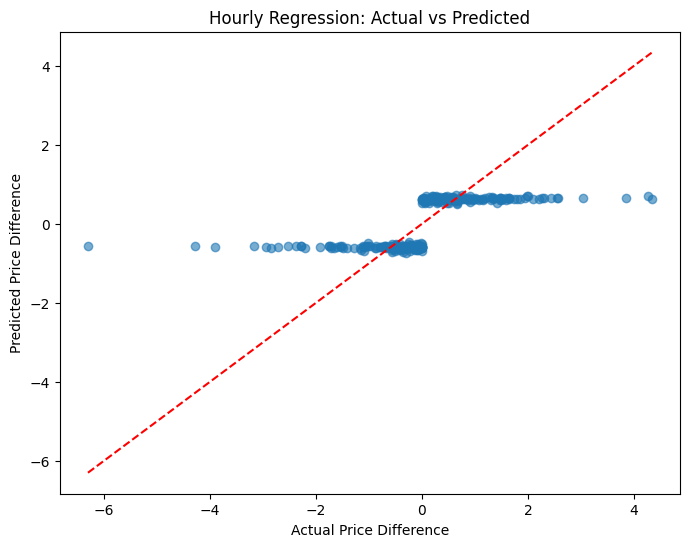

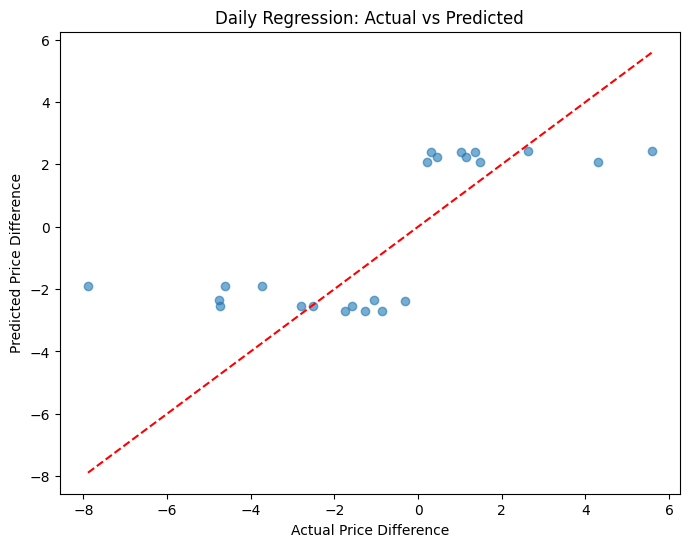

In [220]:
import matplotlib.pyplot as plt

# Hourly regression: actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_hourly_reg, y_pred_hourly_reg, alpha=0.6)
plt.plot([y_test_hourly_reg.min(), y_test_hourly_reg.max()],
         [y_test_hourly_reg.min(), y_test_hourly_reg.max()], color='red', linestyle='--')
plt.xlabel("Actual Price Difference")
plt.ylabel("Predicted Price Difference")
plt.title("Hourly Regression: Actual vs Predicted")
plt.show()

# Daily regression: actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_daily_reg, y_pred_daily_reg, alpha=0.6)
plt.plot([y_test_daily_reg.min(), y_test_daily_reg.max()],
         [y_test_daily_reg.min(), y_test_daily_reg.max()], color='red', linestyle='--')
plt.xlabel("Actual Price Difference")
plt.ylabel("Predicted Price Difference")
plt.title("Daily Regression: Actual vs Predicted")
plt.show()
